# Étape 1 --- Comprendre les systèmes dynamiques et simuler les modèles SIR et SEIR

## Projet de mathématiques pour l'IA

---

## Introduction

Cette première étape du projet a pour objectif de comprendre ce qu'est, de manière générale, un **système dynamique**, puis d'appliquer cette notion à la modélisation d'une épidémie à travers les modèles **SIR** (Kermack et McKendrick, 1927) et **SEIR**.

L'idée n'est pas seulement de donner une définition théorique, mais de montrer comment un phénomène réel --- ici la propagation d'une maladie dans une population --- peut être décrit mathématiquement, simulé numériquement et interprété graphiquement.

Dans ce travail, nous allons :

- présenter la notion générale de système dynamique ;
- expliquer pourquoi une épidémie peut être modélisée par des **équations différentielles ordinaires (EDO)** ;
- étudier les modèles compartimentaux **SIR** et **SEIR** ;
- implémenter leur simulation numérique en Python avec `solve_ivp` (méthode de Runge-Kutta) ;
- analyser et comparer les résultats obtenus ;
- discuter enfin les hypothèses et les limites de ces modèles.

Cette étape constitue donc à la fois une **introduction théorique**, une **mise en pratique mathématique** et une **première approche computationnelle** de la modélisation dynamique.

---

## 1. Introduction générale aux systèmes dynamiques

Un **système dynamique** est un système mathématique qui décrit l'évolution d'un phénomène au cours du temps.

Autrement dit, à chaque instant, le système possède un **état**, et une règle mathématique permet de déterminer comment cet état évolue au fil du temps.

### 1.1 Intuition générale

Dans de nombreux phénomènes réels, les quantités observées ne restent pas fixes :

- une population peut augmenter ou diminuer ;
- une température peut varier ;
- une substance peut se transformer chimiquement ;
- une maladie peut se propager dans une population.

Dans chacun de ces cas, on ne s'intéresse pas seulement à une valeur donnée à un instant précis, mais à la **manière dont cette valeur change avec le temps**.

C'est précisément ce que permet d'étudier un système dynamique.

### 1.2 Éléments constitutifs d'un système dynamique

Un système dynamique comporte généralement quatre éléments fondamentaux :

#### a) Les variables d'état
Ce sont les quantités qui décrivent le système à un instant donné. Par exemple, dans un modèle épidémique, les variables d'état sont les effectifs de chaque compartiment ($S$, $I$, $R$, etc.).

#### b) La loi d'évolution
Elle indique comment ces variables changent dans le temps. Elle est généralement exprimée sous forme d'équations différentielles.

#### c) Les conditions initiales
Elles précisent l'état du système au départ de l'étude. La solution du système dépend de ces conditions.

#### d) Les paramètres
Ce sont des constantes qui influencent la dynamique du système, sans être elles-mêmes des variables d'état. Par exemple, le taux de transmission $\beta$ d'une maladie.

### 1.3 Formulation mathématique

Dans le cas continu, un système dynamique est souvent modélisé par une ou plusieurs équations différentielles ordinaires (EDO) de la forme :

$$
\frac{dx}{dt} = f(x, t)
$$

où :

- $x(t)$ représente l'état du système au temps $t$,
- $\frac{dx}{dt}$ représente la vitesse de variation de cet état,
- $f$ désigne la loi qui gouverne l'évolution du système.

Lorsque $f$ ne dépend pas explicitement de $t$ (uniquement de $x$), on parle de système **autonome**. Les modèles SIR et SEIR que nous étudions sont des systèmes autonomes.

Ainsi, un système dynamique permet de relier l'état présent d'un phénomène à son évolution future.

### 1.4 Pourquoi cette notion est importante

La notion de système dynamique est fondamentale dans de nombreux domaines scientifiques :

- en physique, pour décrire le mouvement (mécanique newtonienne, systèmes oscillants) ;
- en biologie, pour décrire l'évolution de populations (modèle de Lotka-Volterra) ;
- en économie, pour étudier certains phénomènes évolutifs ;
- en épidémiologie, pour modéliser la propagation de maladies ;
- en intelligence artificielle et en modélisation, pour comprendre des processus complexes dans le temps.

Dans notre projet, le système dynamique étudié sera celui d'une **épidémie**, décrite comme une évolution de plusieurs groupes d'individus au cours du temps.

---

## 2. Pourquoi les épidémies peuvent être modélisées par des EDO

Une épidémie n'est pas un phénomène statique. Le nombre de personnes susceptibles, infectées, exposées ou guéries évolue continuellement. Il est donc naturel d'utiliser un modèle mathématique capable de décrire cette évolution dans le temps.

Les **équations différentielles ordinaires** sont particulièrement adaptées à ce type de problème, car elles permettent de représenter la variation d'une quantité en fonction du temps.

### 2.1 Une épidémie comme système dynamique

À un instant donné, l'état de l'épidémie peut être résumé par le nombre de personnes appartenant à différents groupes, appelés **compartiments** (Anderson et May, 1991).

Par exemple :

- $S(t)$ : nombre d'individus **susceptibles**,
- $I(t)$ : nombre d'individus **infectés**,
- $R(t)$ : nombre d'individus **retirés ou guéris**,
- $E(t)$ : nombre d'individus **exposés mais non encore infectieux**.

L'état de l'épidémie à l'instant $t$ est donc donné par le vecteur d'état $(S(t), I(t), R(t))$ pour le modèle SIR, ou $(S(t), E(t), I(t), R(t))$ pour le modèle SEIR.

### 2.2 Pourquoi une équation différentielle ?

Une équation différentielle permet de répondre à des questions comme :

- à quelle vitesse le nombre de personnes infectées augmente-t-il ?
- combien de personnes quittent le groupe des susceptibles par unité de temps ?
- combien de personnes guérissent par unité de temps ?

Autrement dit, elle décrit la **dynamique des transferts entre compartiments**. Le terme $\beta \frac{SI}{N}$, par exemple, traduit le fait que le taux de nouvelles infections est proportionnel au produit du nombre de susceptibles et du nombre d'infectés (hypothèse d'action de masse).

### 2.3 Intérêt de cette modélisation

La modélisation mathématique des épidémies permet :

- de mieux comprendre les mécanismes de propagation ;
- de visualiser l'évolution temporelle d'une maladie ;
- de tester l'effet de certains paramètres (ex. réduction de $\beta$ par le confinement) ;
- de comparer plusieurs modèles ;
- de faire des simulations numériques.

Il faut toutefois garder à l'esprit qu'un modèle n'est qu'une **approximation simplifiée du réel** : il permet de comprendre des mécanismes essentiels, mais il ne reproduit pas nécessairement toute la complexité d'une situation réelle.

---

## 3. Modèle SIR : définition, équations, paramètres, interprétation

Le modèle **SIR** est l'un des modèles les plus classiques en épidémiologie mathématique. Il a été introduit par Kermack et McKendrick en 1927 et décrit la propagation d'une maladie dans une population divisée en trois compartiments.

### 3.1 Les compartiments du modèle SIR

Le modèle distingue :

- **S** : *Susceptible* --- individus sains pouvant contracter la maladie ;
- **I** : *Infected* (ou *Infectious*) --- individus infectés et capables de transmettre la maladie ;
- **R** : *Recovered* (ou *Removed*) --- individus guéris, immunisés, isolés ou retirés de la chaîne de transmission.

On suppose que la population totale est constante (pas de naissance, pas de décès non lié à la maladie, pas de migration) :

$$
N = S(t) + I(t) + R(t)
$$

### 3.2 Schéma de transition (diagramme de flux)

Le modèle suit le schéma compartimental suivant :

```
               beta * S * I / N          gamma * I
  [Susceptibles S] ───────────────> [Infectés I] ───────────────> [Retirés R]
```

Cela signifie qu'un individu commence dans le groupe des susceptibles, peut devenir infecté au taux $\beta \frac{S \cdot I}{N}$, puis quitte l'état infectieux au taux $\gamma$ pour rejoindre le compartiment des retirés.

### 3.3 Équations du modèle SIR

Le modèle SIR s'écrit sous la forme d'un système de trois EDO couplées :

$$
\frac{dS}{dt} = -\beta \frac{SI}{N}
$$

$$
\frac{dI}{dt} = \beta \frac{SI}{N} - \gamma I
$$

$$
\frac{dR}{dt} = \gamma I
$$

On peut vérifier que $\frac{d}{dt}(S + I + R) = 0$, ce qui confirme la conservation de la population totale.

### 3.4 Signification des paramètres

- **$\beta$** (taux de transmission) : nombre moyen de contacts suffisants pour transmettre la maladie par unité de temps. Plus $\beta$ est grand, plus la maladie se propage rapidement.

- **$\gamma$** (taux de guérison ou de retrait) : inverse de la durée moyenne de la période infectieuse. Si $\gamma = 0.1$, la durée moyenne d'infection est de $1/\gamma = 10$ jours.

### 3.5 Interprétation des équations

#### Équation des susceptibles

$$
\frac{dS}{dt} = -\beta \frac{SI}{N}
$$

Le nombre de susceptibles diminue au cours du temps. Le terme $\beta \frac{SI}{N}$ représente le taux de nouvelles infections : il est proportionnel au nombre de susceptibles, au nombre d'infectés, et au taux de transmission. C'est l'hypothèse d'**action de masse**.

#### Équation des infectés

$$
\frac{dI}{dt} = \beta \frac{SI}{N} - \gamma I
$$

Le nombre d'infectés évolue sous l'effet de deux flux opposés : il augmente grâce aux nouvelles contaminations ($\beta \frac{SI}{N}$) et diminue à cause des guérisons ($\gamma I$).

#### Équation des retirés

$$
\frac{dR}{dt} = \gamma I
$$

Le nombre d'individus retirés augmente au fur et à mesure des guérisons, à un taux proportionnel au nombre d'infectés.

### 3.6 Nombre de reproduction de base $R_0$

Dans le cadre du modèle SIR, on définit le nombre de reproduction de base :

$$
R_0 = \frac{\beta}{\gamma}
$$

**Interprétation** : $R_0$ représente le nombre moyen de personnes qu'un individu infecté contamine durant toute sa période infectieuse, lorsque toute la population est susceptible.

- Si $R_0 > 1$ : chaque infecté génère plus d'un nouvel infecté en moyenne, donc la maladie peut se propager dans la population (phase épidémique).
- Si $R_0 < 1$ : chaque infecté génère moins d'un nouvel infecté en moyenne, donc l'épidémie tend à s'éteindre.
- Si $R_0 = 1$ : seuil critique, l'épidémie est à l'équilibre.

### 3.7 Analyse qualitative : points d'équilibre

L'analyse des points d'équilibre d'un système dynamique consiste à chercher les états où les dérivées s'annulent simultanément ($\frac{dS}{dt} = \frac{dI}{dt} = \frac{dR}{dt} = 0$).

Pour le modèle SIR, le seul point d'équilibre épidémiologiquement pertinent est l'**équilibre sans maladie** (Disease-Free Equilibrium, DFE) :

$$
(S^*, I^*, R^*) = (S_\infty, 0, N - S_\infty)
$$

où $S_\infty$ est le nombre final de susceptibles, qui dépend des conditions initiales et de $R_0$.

Il n'existe pas d'équilibre endémique dans le modèle SIR classique (sans naissance ni décès), car une fois que $I(t) = 0$, le système reste dans cet état. Le modèle SIR décrit donc une épidémie transitoire, et non un état endémique permanent.

Le modèle SIR constitue ainsi une première représentation simple mais très instructive d'un phénomène épidémique.

---

## 4. Modèle SEIR : ajout du compartiment exposé, équations, intérêt

Le modèle **SEIR** est une extension du modèle SIR. Il ajoute un compartiment supplémentaire afin de représenter une phase intermédiaire entre la contamination et la contagiosité.

### 4.1 Le compartiment E

Dans certaines maladies (grippe, COVID-19, rougeole), un individu ne devient pas contagieux immédiatement après avoir été contaminé. Il passe d'abord par une phase dite **latente** ou **d'incubation**.

Le modèle SEIR introduit alors le compartiment :

- **E** : *Exposed* --- individus contaminés mais pas encore infectieux. La durée moyenne de cette phase est $1/\sigma$.

### 4.2 Compartiments du modèle SEIR

Le modèle contient donc quatre groupes :

- $S(t)$ : susceptibles,
- $E(t)$ : exposés (latents),
- $I(t)$ : infectés infectieux,
- $R(t)$ : retirés ou guéris.

La population totale reste constante :

$$
N = S(t) + E(t) + I(t) + R(t)
$$

### 4.3 Schéma de transition (diagramme de flux)

```
               beta*S*I/N          sigma*E            gamma*I
  [Susceptibles S] ──────> [Exposés E] ──────> [Infectés I] ──────> [Retirés R]
```

Ce schéma traduit l'idée suivante :

1. un individu sain peut être contaminé (passage de S à E) ;
2. il passe alors dans l'état exposé (latent, non contagieux) ;
3. après une période moyenne de $1/\sigma$ jours, il devient infectieux (passage de E à I) ;
4. il finit ensuite par guérir ou être retiré après une période moyenne de $1/\gamma$ jours (passage de I à R).

### 4.4 Équations du modèle SEIR

$$
\frac{dS}{dt} = -\beta \frac{SI}{N}
$$

$$
\frac{dE}{dt} = \beta \frac{SI}{N} - \sigma E
$$

$$
\frac{dI}{dt} = \sigma E - \gamma I
$$

$$
\frac{dR}{dt} = \gamma I
$$

On vérifie de même que $\frac{d}{dt}(S + E + I + R) = 0$ : la population totale est conservée.

### 4.5 Signification des paramètres

- **$\beta$** : taux de transmission (identique au modèle SIR) ;
- **$\sigma$** : taux de passage de l'état exposé vers l'état infectieux. $1/\sigma$ est la durée moyenne de la période de latence ;
- **$\gamma$** : taux de guérison. $1/\gamma$ est la durée moyenne de la période infectieuse.

### 4.6 Nombre de reproduction de base $R_0$ du modèle SEIR

Dans le modèle SEIR simplifié (sans mortalité dans le compartiment E, sans naissance ni décès naturels), le nombre de reproduction de base s'écrit :

$$
R_0 = \frac{\beta}{\gamma}
$$

Cette expression est identique à celle du modèle SIR. En effet, le compartiment E n'affecte pas le nombre moyen de transmissions par individu infecté : il introduit seulement un **délai temporel** entre la contamination et la contagiosité, mais ne modifie pas le nombre total de personnes qu'un individu infecté contaminera. Le $R_0$ dépend uniquement du rapport entre la capacité de transmission ($\beta$) et la vitesse de guérison ($\gamma$).

### 4.7 Intérêt du modèle SEIR

Le modèle SEIR est particulièrement utile lorsque la maladie comporte un délai significatif entre la contamination et la possibilité de transmettre l'infection.

Par rapport au modèle SIR, il permet :

- une description plus réaliste de maladies avec période d'incubation ;
- l'introduction d'un temps de latence quantifiable ($1/\sigma$) ;
- une dynamique différente, souvent plus progressive dans la montée des infections ;
- un décalage du pic infectieux dans le temps.

Le modèle SEIR affine donc l'analyse dynamique de l'épidémie tout en conservant la même valeur de $R_0$.

---

## 5. Simulation numérique avec Python (`solve_ivp`)

L'étude théorique des équations différentielles est essentielle, mais dans la plupart des cas, les systèmes d'EDO non linéaires comme SIR et SEIR n'admettent pas de solution analytique explicite. On a donc recours à une **résolution numérique** pour observer concrètement l'évolution des compartiments au cours du temps.

En Python, la fonction `solve_ivp` du module `scipy.integrate` permet de résoudre numériquement un système différentiel muni de conditions initiales. Par défaut, elle utilise la **méthode RK45** (Runge-Kutta d'ordre 4/5 avec contrôle adaptatif du pas), qui est bien adaptée aux systèmes non raides comme SIR et SEIR (Dormand et Prince, 1980).

### 5.1 Importation des bibliothèques

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

### 5.2 Définition du modèle SIR en Python

In [2]:
def sir_model(t, y, beta, gamma, N):
    """
    Système d'EDO du modèle SIR.

    Paramètres
    ----------
    t : float
        Variable de temps (non utilisée explicitement car le système est autonome).
    y : array-like
        Vecteur d'état [S, I, R].
    beta : float
        Taux de transmission.
    gamma : float
        Taux de guérison.
    N : int
        Population totale.

    Retourne
    --------
    list
        Dérivées [dS/dt, dI/dt, dR/dt].
    """
    S, I, R = y

    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I

    return [dSdt, dIdt, dRdt]

### 5.3 Définition du modèle SEIR en Python

In [3]:
def seir_model(t, y, beta, sigma, gamma, N):
    """
    Système d'EDO du modèle SEIR.

    Paramètres
    ----------
    t : float
        Variable de temps (non utilisée explicitement car le système est autonome).
    y : array-like
        Vecteur d'état [S, E, I, R].
    beta : float
        Taux de transmission.
    sigma : float
        Taux de transition exposé -> infectieux (inverse de la période de latence).
    gamma : float
        Taux de guérison.
    N : int
        Population totale.

    Retourne
    --------
    list
        Dérivées [dS/dt, dE/dt, dI/dt, dR/dt].
    """
    S, E, I, R = y

    dSdt = -beta * S * I / N
    dEdt = beta * S * I / N - sigma * E
    dIdt = sigma * E - gamma * I
    dRdt = gamma * I

    return [dSdt, dEdt, dIdt, dRdt]

### 5.4 Choix des paramètres et des conditions initiales

Les valeurs choisies ci-dessous sont représentatives d'un scénario épidémique de type grippe saisonnière, couramment utilisé dans la littérature pédagogique (Hethcote, 2000). La population de $N = 1000$ permet des simulations rapides tout en conservant des proportions interprétables.

In [4]:
# Population totale
N = 1000

# Conditions initiales
I_init = 1       # Un seul individu infecté au départ
R_init = 0       # Aucun individu guéri au départ
S_init = N - I_init - R_init   # Le reste de la population est susceptible
E_init = 0       # Aucun individu exposé au départ (pour SEIR)

# Paramètres épidémiologiques
beta = 0.3       # Taux de transmission (contacts infectieux par jour)
gamma = 0.1      # Taux de guérison (durée moyenne d'infection : 1/0.1 = 10 jours)
sigma = 0.2      # Taux de passage E -> I (durée moyenne de latence : 1/0.2 = 5 jours)

# Temps de simulation (en jours)
t_start = 0
t_end = 160
t_eval = np.linspace(t_start, t_end, 1000)

# Nombre de reproduction de base
R_0 = beta / gamma
print(f"Nombre de reproduction de base : R0 = {R_0:.2f}")
print(f"Durée moyenne de la période infectieuse : {1/gamma:.0f} jours")
print(f"Durée moyenne de la période de latence (SEIR) : {1/sigma:.0f} jours")

Nombre de reproduction de base : R0 = 3.00
Durée moyenne de la période infectieuse : 10 jours
Durée moyenne de la période de latence (SEIR) : 5 jours


Avec $\beta = 0.3$ et $\gamma = 0.1$, on obtient $R_0 = 3.0 > 1$ : l'épidémie peut se propager.

### 5.5 Résolution numérique du modèle SIR

In [5]:
# Résolution du système SIR par la méthode RK45 (Runge-Kutta adaptatif)
sir_solution = solve_ivp(
    fun=lambda t, y: sir_model(t, y, beta, gamma, N),
    t_span=(t_start, t_end),
    y0=[S_init, I_init, R_init],
    t_eval=t_eval,
    method='RK45'
)

# Extraction des solutions
S_sir = sir_solution.y[0]
I_sir = sir_solution.y[1]
R_sir = sir_solution.y[2]

### 5.6 Résolution numérique du modèle SEIR

In [6]:
# Résolution du système SEIR par la méthode RK45
seir_solution = solve_ivp(
    fun=lambda t, y: seir_model(t, y, beta, sigma, gamma, N),
    t_span=(t_start, t_end),
    y0=[S_init, E_init, I_init, R_init],
    t_eval=t_eval,
    method='RK45'
)

# Extraction des solutions
S_seir = seir_solution.y[0]
E_seir = seir_solution.y[1]
I_seir = seir_solution.y[2]
R_seir = seir_solution.y[3]

---

## 6. Résultats : visualisation des courbes

Une fois les systèmes résolus numériquement, il devient possible de représenter graphiquement l'évolution de chaque compartiment.

### 6.1 Visualisation du modèle SIR

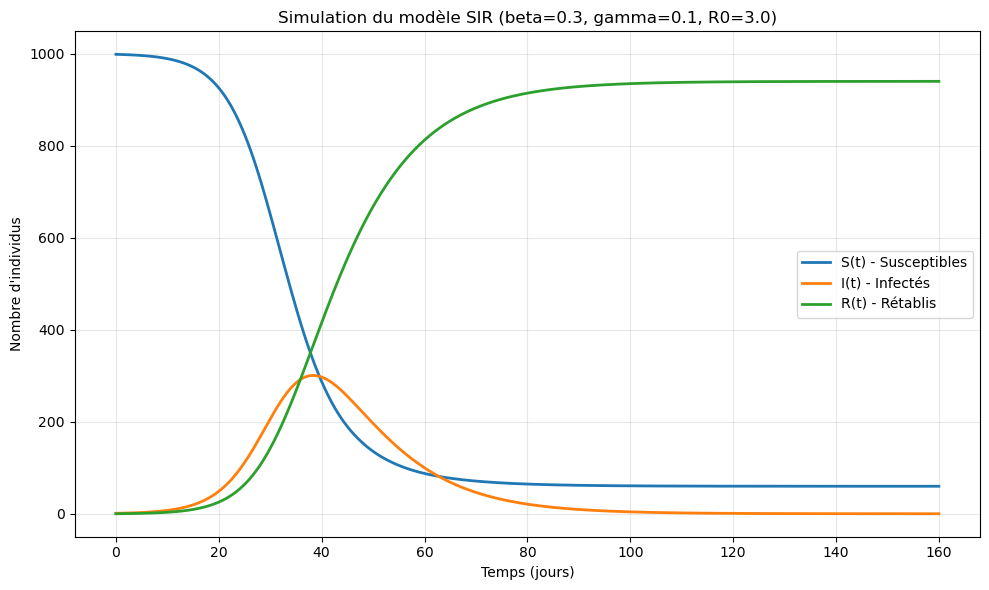

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(t_eval, S_sir, label='S(t) - Susceptibles', linewidth=2)
plt.plot(t_eval, I_sir, label='I(t) - Infectés', linewidth=2)
plt.plot(t_eval, R_sir, label='R(t) - Rétablis', linewidth=2)
plt.xlabel("Temps (jours)")
plt.ylabel("Nombre d'individus")
plt.title(f"Simulation du modèle SIR (beta={beta}, gamma={gamma}, R0={R_0:.1f})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6.2 Interprétation du modèle SIR

Les résultats numériques (les valeurs exactes seront calculées en section 7.3) permettent d'observer le comportement typique d'une épidémie décrite par le modèle SIR :

- le nombre de susceptibles $S(t)$ décroît de manière monotone : les individus quittent ce compartiment en étant contaminés ;
- le nombre d'infectés $I(t)$ suit une courbe en cloche : il augmente au début lorsque le taux de nouvelles infections dépasse le taux de guérison, atteint un maximum (le **pic épidémique**), puis décroît lorsque la diminution du nombre de susceptibles ralentit suffisamment la transmission ;
- le nombre de retirés $R(t)$ croît de manière monotone et se stabilise à la valeur finale $R(\infty)$.

Ce comportement traduit le mécanisme fondamental d'une épidémie : la propagation est initialement forte car presque toute la population est susceptible, puis elle ralentit à mesure que les susceptibles diminuent.

### 6.3 Visualisation du modèle SEIR

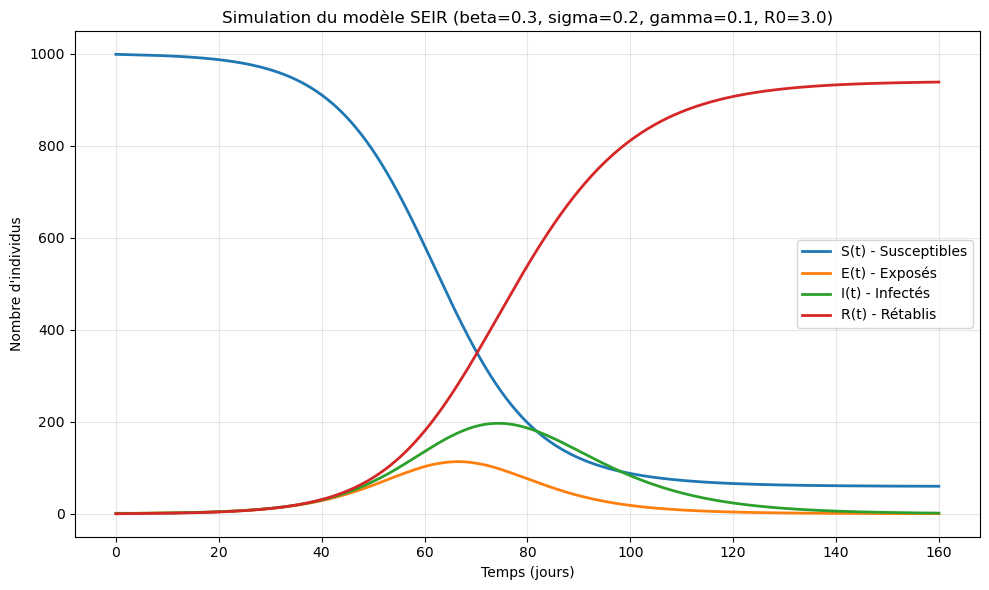

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(t_eval, S_seir, label='S(t) - Susceptibles', linewidth=2)
plt.plot(t_eval, E_seir, label='E(t) - Exposés', linewidth=2)
plt.plot(t_eval, I_seir, label='I(t) - Infectés', linewidth=2)
plt.plot(t_eval, R_seir, label='R(t) - Rétablis', linewidth=2)
plt.xlabel("Temps (jours)")
plt.ylabel("Nombre d'individus")
plt.title(f"Simulation du modèle SEIR (beta={beta}, sigma={sigma}, gamma={gamma}, R0={R_0:.1f})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6.4 Interprétation du modèle SEIR

Dans le modèle SEIR, l'introduction du compartiment exposé modifie la dynamique de l'épidémie par rapport au modèle SIR :

- la courbe $E(t)$ des exposés présente également une forme en cloche, mais son pic précède celui des infectés : les individus passent d'abord par l'état exposé avant de devenir infectieux ;
- la montée du nombre d'infectés $I(t)$ est plus progressive, car il faut un délai (en moyenne $1/\sigma$ jours) pour qu'un individu contaminé devienne infectieux ;
- le pic infectieux est généralement **décalé dans le temps** et peut être légèrement **atténué** par rapport au modèle SIR ;
- la dynamique globale est plus lente à s'installer, ce qui se traduit par une courbe $S(t)$ qui décroît un peu plus tardivement.

Le compartiment $E$ permet donc une représentation plus fine du phénomène, particulièrement adaptée aux maladies avec une période d'incubation significative.

---

## 7. Comparaison SIR vs SEIR

Les modèles SIR et SEIR sont proches dans leur logique, mais ils ne décrivent pas exactement la même réalité. Cette section compare quantitativement leurs résultats.

### 7.1 Tableau comparatif

| Élément | Modèle SIR | Modèle SEIR |
|---------|------------|-------------|
| Compartiments | S, I, R | S, E, I, R |
| Phase de latence | Non | Oui ($1/\sigma$ jours) |
| Nombre de paramètres | 2 ($\beta$, $\gamma$) | 3 ($\beta$, $\sigma$, $\gamma$) |
| $R_0$ | $\beta / \gamma$ | $\beta / \gamma$ (identique) |
| Complexité du système | 3 EDO | 4 EDO |
| Réalisme | Première approche | Meilleur si période de latence |
| Pic épidémique | Plus précoce | Décalé dans le temps |
| Usage typique | Analyse pédagogique | Modélisation plus réaliste |

### 7.2 Comparaison directe des courbes d'infectés

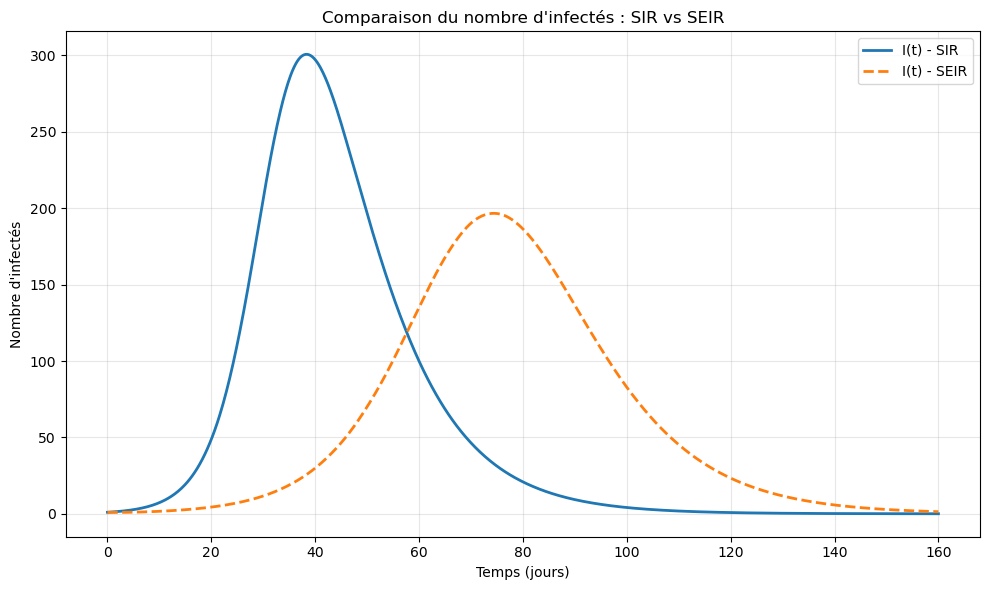

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(t_eval, I_sir, label='I(t) - SIR', linewidth=2)
plt.plot(t_eval, I_seir, label='I(t) - SEIR', linewidth=2, linestyle='--')
plt.xlabel("Temps (jours)")
plt.ylabel("Nombre d'infectés")
plt.title("Comparaison du nombre d'infectés : SIR vs SEIR")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 7.3 Calcul du pic infectieux

In [10]:
# Pic infectieux et temps d'occurrence pour le modèle SIR
peak_I_sir = np.max(I_sir)
time_peak_sir = t_eval[np.argmax(I_sir)]

# Pic infectieux et temps d'occurrence pour le modèle SEIR
peak_I_seir = np.max(I_seir)
time_peak_seir = t_eval[np.argmax(I_seir)]

print("=" * 50)
print("RÉSULTATS QUANTITATIFS")
print("=" * 50)
print(f"\n--- Modèle SIR ---")
print(f"Pic infectieux       : {peak_I_sir:.2f} individus")
print(f"Temps du pic         : jour {time_peak_sir:.2f}")

print(f"\n--- Modèle SEIR ---")
print(f"Pic infectieux       : {peak_I_seir:.2f} individus")
print(f"Temps du pic         : jour {time_peak_seir:.2f}")

print(f"\n--- Comparaison ---")
print(f"Décalage du pic      : {time_peak_seir - time_peak_sir:.2f} jours")
print(f"Différence de hauteur: {peak_I_sir - peak_I_seir:.2f} individus")

RÉSULTATS QUANTITATIFS

--- Modèle SIR ---
Pic infectieux       : 300.74 individus
Temps du pic         : jour 38.28

--- Modèle SEIR ---
Pic infectieux       : 196.65 individus
Temps du pic         : jour 74.31

--- Comparaison ---
Décalage du pic      : 36.04 jours
Différence de hauteur: 104.09 individus


### 7.4 Vérification de la conservation de la population

Cette vérification numérique confirme que la résolution par `solve_ivp` préserve bien la contrainte $S + I + R = N$ (resp. $S + E + I + R = N$). Une variation significative indiquerait une erreur d'implémentation ou une précision numérique insuffisante.

In [11]:
total_sir = S_sir + I_sir + R_sir
total_seir = S_seir + E_seir + I_seir + R_seir

print(f"Variation maximale de la population totale (SIR)  : {np.max(np.abs(total_sir - N)):.2e}")
print(f"Variation maximale de la population totale (SEIR) : {np.max(np.abs(total_seir - N)):.2e}")

Variation maximale de la population totale (SIR)  : 2.27e-13
Variation maximale de la population totale (SEIR) : 2.27e-13


### 7.5 Interprétation générale de la comparaison

La comparaison quantitative confirme les prédictions théoriques :

- Le pic infectieux du modèle SEIR est **décalé dans le temps** par rapport à celui du modèle SIR, en raison du délai induit par la période de latence ($1/\sigma$ jours).
- La hauteur du pic peut être légèrement différente entre les deux modèles, car l'étalement temporel du passage E à I modifie le profil de la courbe des infectés.
- Les deux modèles partagent le même $R_0$, donc la même condition de propagation de l'épidémie. La différence réside dans la **dynamique temporelle**, non dans le seuil épidémique.

Le modèle SIR reste très utile pour comprendre les mécanismes fondamentaux d'une propagation épidémique. Le modèle SEIR l'enrichit en introduisant un réalisme supplémentaire pour les maladies avec incubation.

---

## 8. Analyse de sensibilité aux paramètres

L'analyse de sensibilité consiste à observer comment les résultats de la simulation changent lorsqu'on modifie la valeur des paramètres. C'est une étape essentielle dans toute étude de modélisation.

### 8.1 Scénario 1 : épidémie qui s'éteint ($R_0 < 1$)

Scénario 1 : R0 = 0.80 (< 1, extinction attendue)


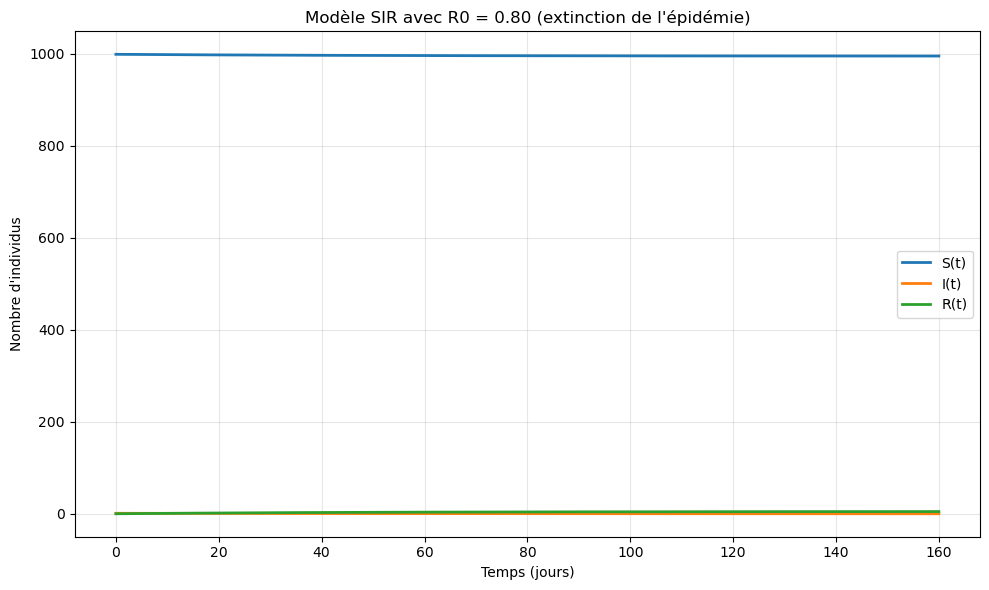

In [12]:
# Scénario : beta = 0.08, gamma = 0.1 => R0 = 0.8 < 1
beta_low = 0.08
R_0_low = beta_low / gamma
print(f"Scénario 1 : R0 = {R_0_low:.2f} (< 1, extinction attendue)")

sir_ext = solve_ivp(
    fun=lambda t, y: sir_model(t, y, beta_low, gamma, N),
    t_span=(t_start, t_end),
    y0=[S_init, I_init, R_init],
    t_eval=t_eval,
    method='RK45'
)

plt.figure(figsize=(10, 6))
plt.plot(t_eval, sir_ext.y[0], label='S(t)', linewidth=2)
plt.plot(t_eval, sir_ext.y[1], label='I(t)', linewidth=2)
plt.plot(t_eval, sir_ext.y[2], label='R(t)', linewidth=2)
plt.xlabel("Temps (jours)")
plt.ylabel("Nombre d'individus")
plt.title(f"Modèle SIR avec R0 = {R_0_low:.2f} (extinction de l'épidémie)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Avec $R_0 = 0.8 < 1$, on observe que le nombre d'infectés décroît depuis le début sans jamais former de pic significatif. L'épidémie ne parvient pas à se propager dans la population.

### 8.2 Scénario 2 : épidémie très contagieuse ($R_0 \gg 1$)

Scénario 2 : R0 = 10.00 (>> 1, forte propagation)


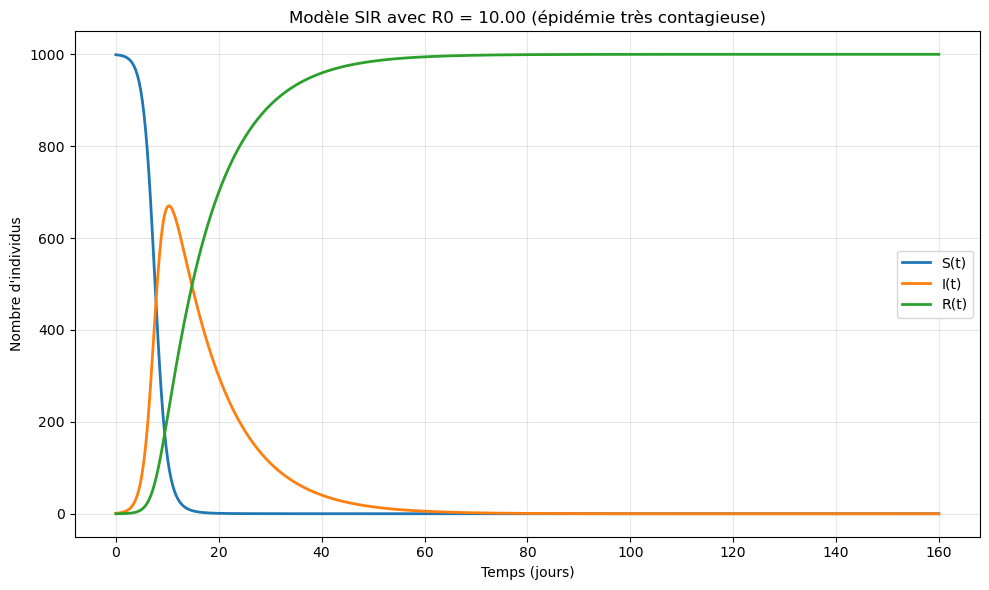

Pic infectieux : 670.11 individus
Temps du pic   : jour 10.25


In [13]:
# Scénario : beta = 1.0, gamma = 0.1 => R0 = 10
beta_high = 1.0
R_0_high = beta_high / gamma
print(f"Scénario 2 : R0 = {R_0_high:.2f} (>> 1, forte propagation)")

sir_high = solve_ivp(
    fun=lambda t, y: sir_model(t, y, beta_high, gamma, N),
    t_span=(t_start, t_end),
    y0=[S_init, I_init, R_init],
    t_eval=t_eval,
    method='RK45'
)

plt.figure(figsize=(10, 6))
plt.plot(t_eval, sir_high.y[0], label='S(t)', linewidth=2)
plt.plot(t_eval, sir_high.y[1], label='I(t)', linewidth=2)
plt.plot(t_eval, sir_high.y[2], label='R(t)', linewidth=2)
plt.xlabel("Temps (jours)")
plt.ylabel("Nombre d'individus")
plt.title(f"Modèle SIR avec R0 = {R_0_high:.2f} (épidémie très contagieuse)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Pic infectieux : {np.max(sir_high.y[1]):.2f} individus")
print(f"Temps du pic   : jour {t_eval[np.argmax(sir_high.y[1])]:.2f}")

Avec $R_0 = 10$, le pic infectieux est très élevé et survient beaucoup plus tôt. Presque toute la population est touchée. Ce scénario illustre l'importance des mesures de réduction de $\beta$ (confinement, distanciation).

### 8.3 Synthèse de l'analyse de sensibilité

| Scénario | $\beta$ | $\gamma$ | $R_0$ | Comportement |
|----------|---------|----------|-------|--------------|
| Extinction | 0.08 | 0.1 | 0.8 | Pas de propagation, décroissance monotone de I(t) |
| Référence | 0.3 | 0.1 | 3.0 | Épidémie modérée, pic marqué |
| Forte contagion | 1.0 | 0.1 | 10.0 | Épidémie rapide et intense, pic très élevé |

---

## 9. Hypothèses, limites et conclusion

### 9.1 Hypothèses des modèles

Les modèles SIR et SEIR reposent sur des hypothèses simplificatrices importantes :

1. **Population homogène** : tous les individus ont les mêmes caractéristiques (âge, état de santé, comportement).
2. **Mélange uniforme** : chaque individu a la même probabilité de rencontrer n'importe quel autre individu (hypothèse d'action de masse).
3. **Paramètres constants** : $\beta$, $\gamma$ et $\sigma$ ne varient pas au cours du temps.
4. **Population fermée** : pas de naissance, de décès naturel ni de migration.
5. **Immunité permanente** : une fois guéri, un individu ne peut plus être réinfecté.

Ces hypothèses facilitent l'étude mathématique et la résolution numérique, mais réduisent le réalisme du modèle.

### 9.2 Limites

Dans la réalité :

- les individus n'ont pas tous le même nombre de contacts (hétérogénéité sociale et spatiale) ;
- les paramètres peuvent varier selon le temps (mesures sanitaires, saisonnalité) ou selon les sous-populations ;
- il peut exister des vaccinations, des décès liés à la maladie, des naissances ou des migrations ;
- les données épidémiologiques sont souvent incomplètes, bruitées ou décalées dans le temps ;
- certaines maladies ne confèrent pas d'immunité permanente (modèles SIS, SIRS).

Les modèles SIR et SEIR ne constituent donc pas une reproduction exacte du réel, mais plutôt une **représentation simplifiée** permettant de comprendre les mécanismes essentiels de la propagation.

### 9.3 Conclusion générale

Au cours de cette étape, nous avons montré qu'une épidémie peut être étudiée comme un **système dynamique**, car son état évolue dans le temps selon un système d'équations différentielles.

Nous avons présenté deux modèles compartimentaux classiques :

- le modèle **SIR**, simple, pédagogique et fondamental, introduit par Kermack et McKendrick (1927) ;
- le modèle **SEIR**, plus riche grâce à l'introduction du compartiment exposé.

Nous avons résolu numériquement ces systèmes à l'aide de la méthode RK45 implémentée dans `scipy.integrate.solve_ivp`, et visualisé leur comportement. La comparaison quantitative des résultats montre que le modèle SEIR introduit un décalage temporel du pic épidémique par rapport au modèle SIR, tandis que le seuil de propagation ($R_0$) reste identique.

L'analyse de sensibilité a permis de vérifier le rôle déterminant du nombre de reproduction de base $R_0$ : selon sa valeur, l'épidémie peut s'éteindre, se propager modérément ou exploser.

Cette étape constitue ainsi une base solide pour la suite du projet.

---

## 10. Ouverture

Pour aller plus loin, plusieurs extensions sont envisageables :

- **Vaccination** : ajout d'un flux $S \to R$ à un taux $\nu$, ce qui modifie l'équation $\frac{dS}{dt} = -\beta \frac{SI}{N} - \nu S$ et réduit le $R_0$ effectif.
- **Paramètres variables dans le temps** : remplacement de $\beta$ par une fonction $\beta(t)$ pour simuler l'effet d'un confinement (ex. $\beta(t) = \beta_0 \cdot e^{-kt}$).
- **Démographie** : introduction de termes de naissance ($\mu N$) et de mortalité ($\mu$) dans chaque équation, ce qui peut faire apparaître un équilibre endémique.
- **Ajustement à des données réelles** : calibration des paramètres $\beta$, $\gamma$, $\sigma$ sur des données épidémiologiques réelles par optimisation (moindres carrés, maximum de vraisemblance).
- **Interface interactive** : développement d'un simulateur avec Streamlit permettant de modifier les paramètres en temps réel et d'observer immédiatement leur effet sur la dynamique.

Une telle interface permettrait de mieux visualiser l'influence des paramètres sur la dynamique du système et de rendre la simulation plus intuitive et pédagogique.

---

## Références

1. Kermack, W. O. et McKendrick, A. G. (1927). "A Contribution to the Mathematical Theory of Epidemics". *Proceedings of the Royal Society A*, 115(772), 700-721.
2. Hethcote, H. W. (2000). "The Mathematics of Infectious Diseases". *SIAM Review*, 42(4), 599-653.
3. Anderson, R. M. et May, R. M. (1991). *Infectious Diseases of Humans: Dynamics and Control*. Oxford University Press.
4. Dormand, J. R. et Prince, P. J. (1980). "A family of embedded Runge-Kutta formulae". *Journal of Computational and Applied Mathematics*, 6(1), 19-26.
5. Virtanen, P. et al. (2020). "SciPy 1.0: Fundamental Algorithms for Scientific Computing in Python". *Nature Methods*, 17, 261-272.